# Breast Cancer Classification: Model Comparison and Diagnostic Metrics

Comparing supervised learning models with emphasis on sensitivity, specificity, ROC-AUC, and classification-threshold trade-offs.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Train/test split and cross-validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV
)

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    make_scorer, 
    recall_score
)
from sklearn.inspection import permutation_importance

# Make nicer-looking plots (font sizes and other parameters)
import plot_utils  

## Load and inspect the data

In [2]:
# Load the Wisconsin Diagnostic Breast Cancer dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target
df["target"] = data.target

# sklearn encodes the target as: 0 = malignant, 1 = benign
# For clearer interpretation of the forthcoming sensitivity/specificity analysis, 
# we redefine the target so that malignant = 1 (bening = 0):
df["target"] = (df["target"] == 0).astype(int)
print(f"Class distribution:")
vc = df["target"].value_counts()
print(f"  Benign (0)    : {vc[0]}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Malignant (1) : {vc[1]}  ({vc[1]/len(df)*100:.1f}%)")

df.head()

Class distribution:
  Benign (0)    : 357  (62.7%)
  Malignant (1) : 212  (37.3%)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
# The dataset has 10 features measured, from which we have the mean, error, and "worst" (mean of 
# the three largest values).
print(df.info())
print(df.describe().round(3))

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

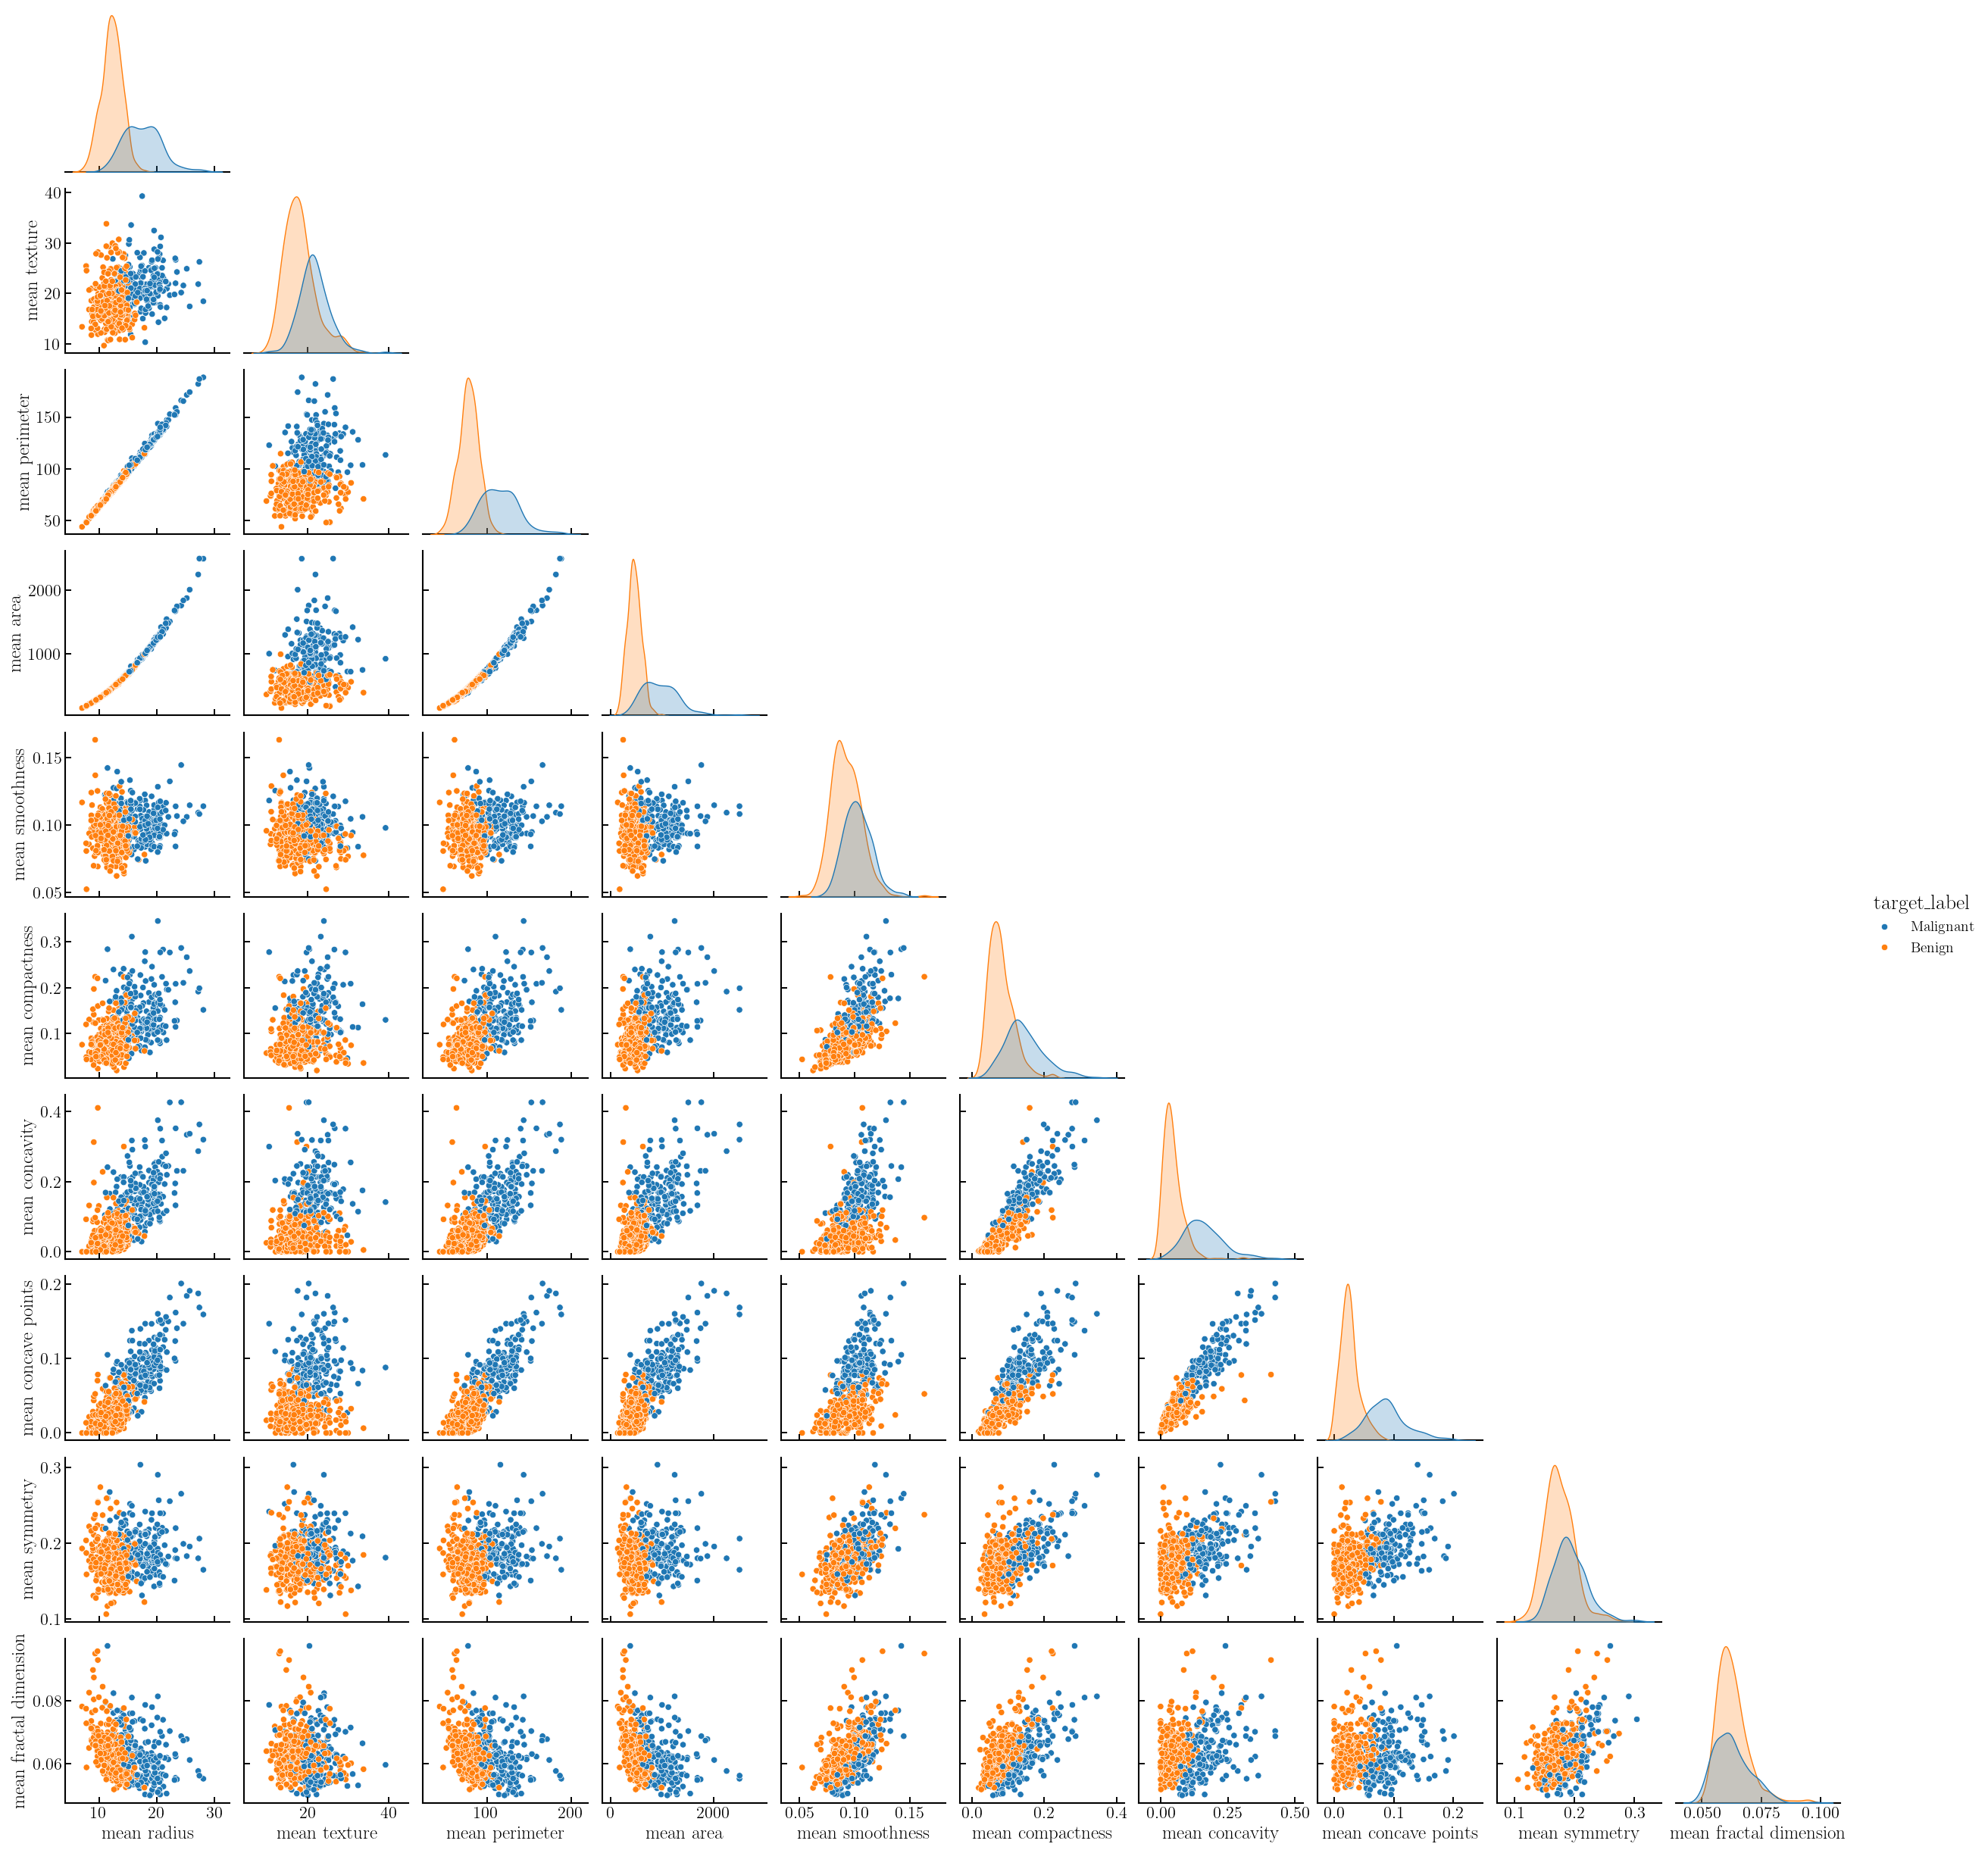

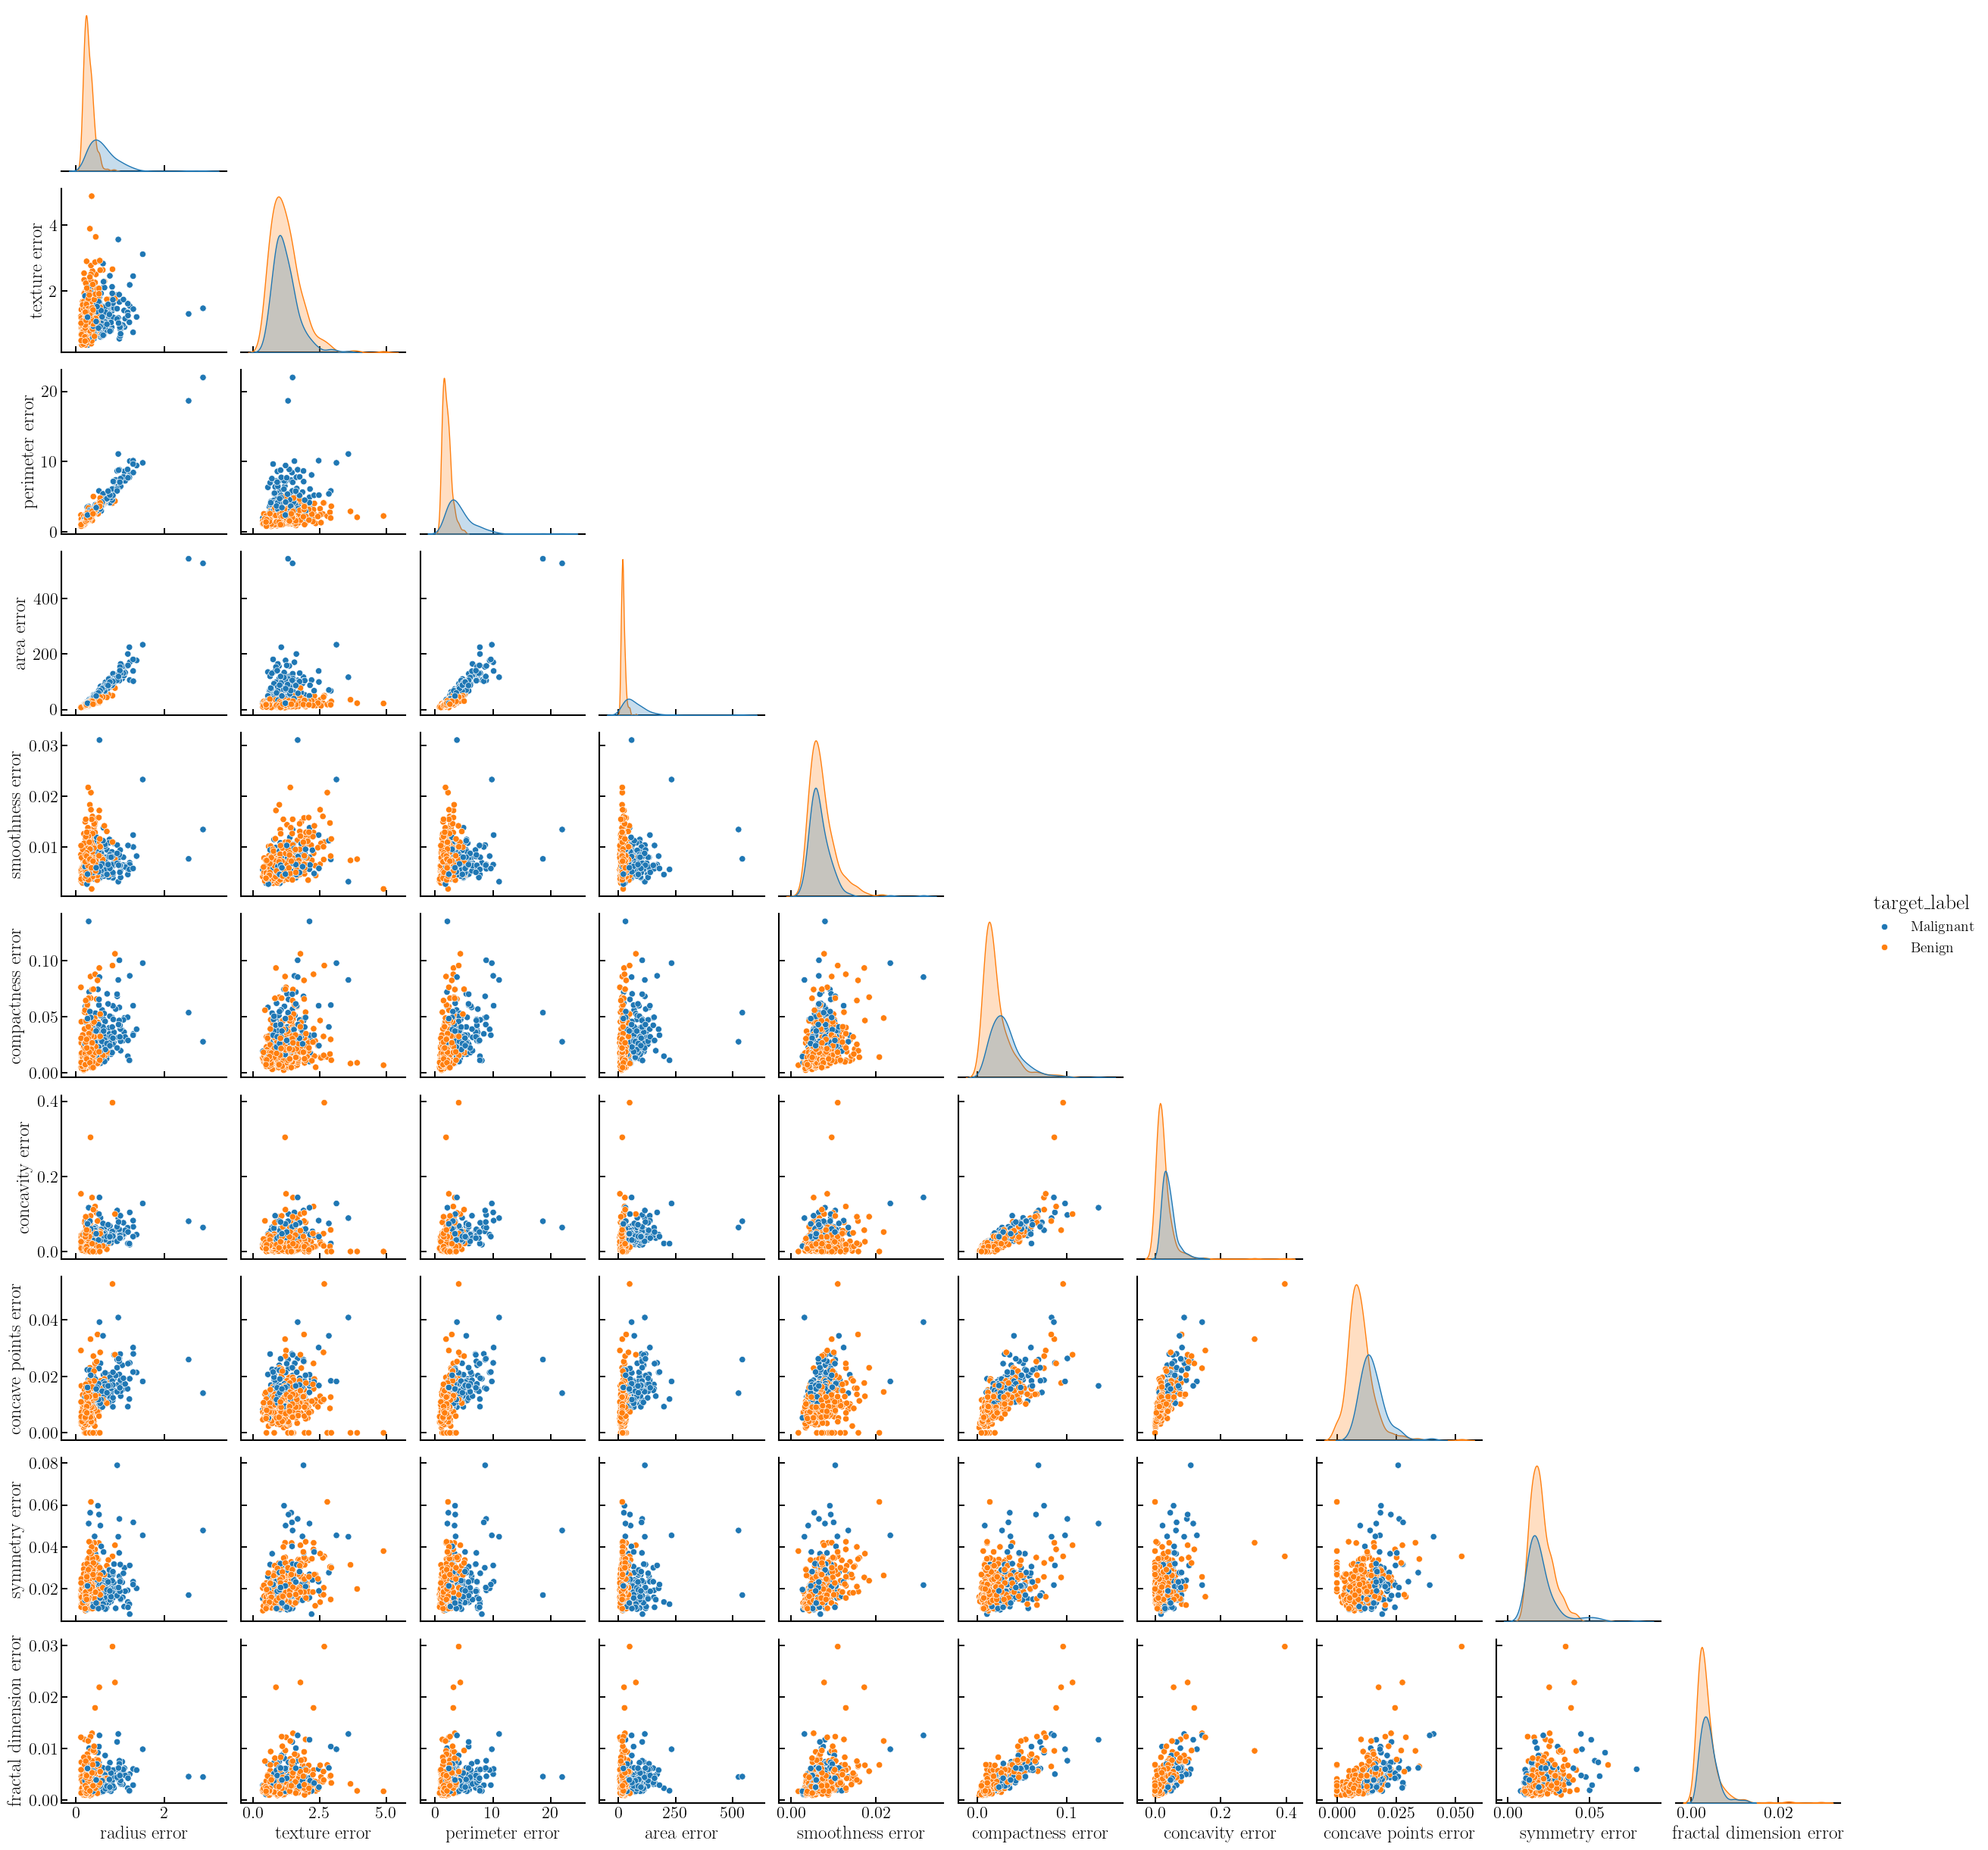

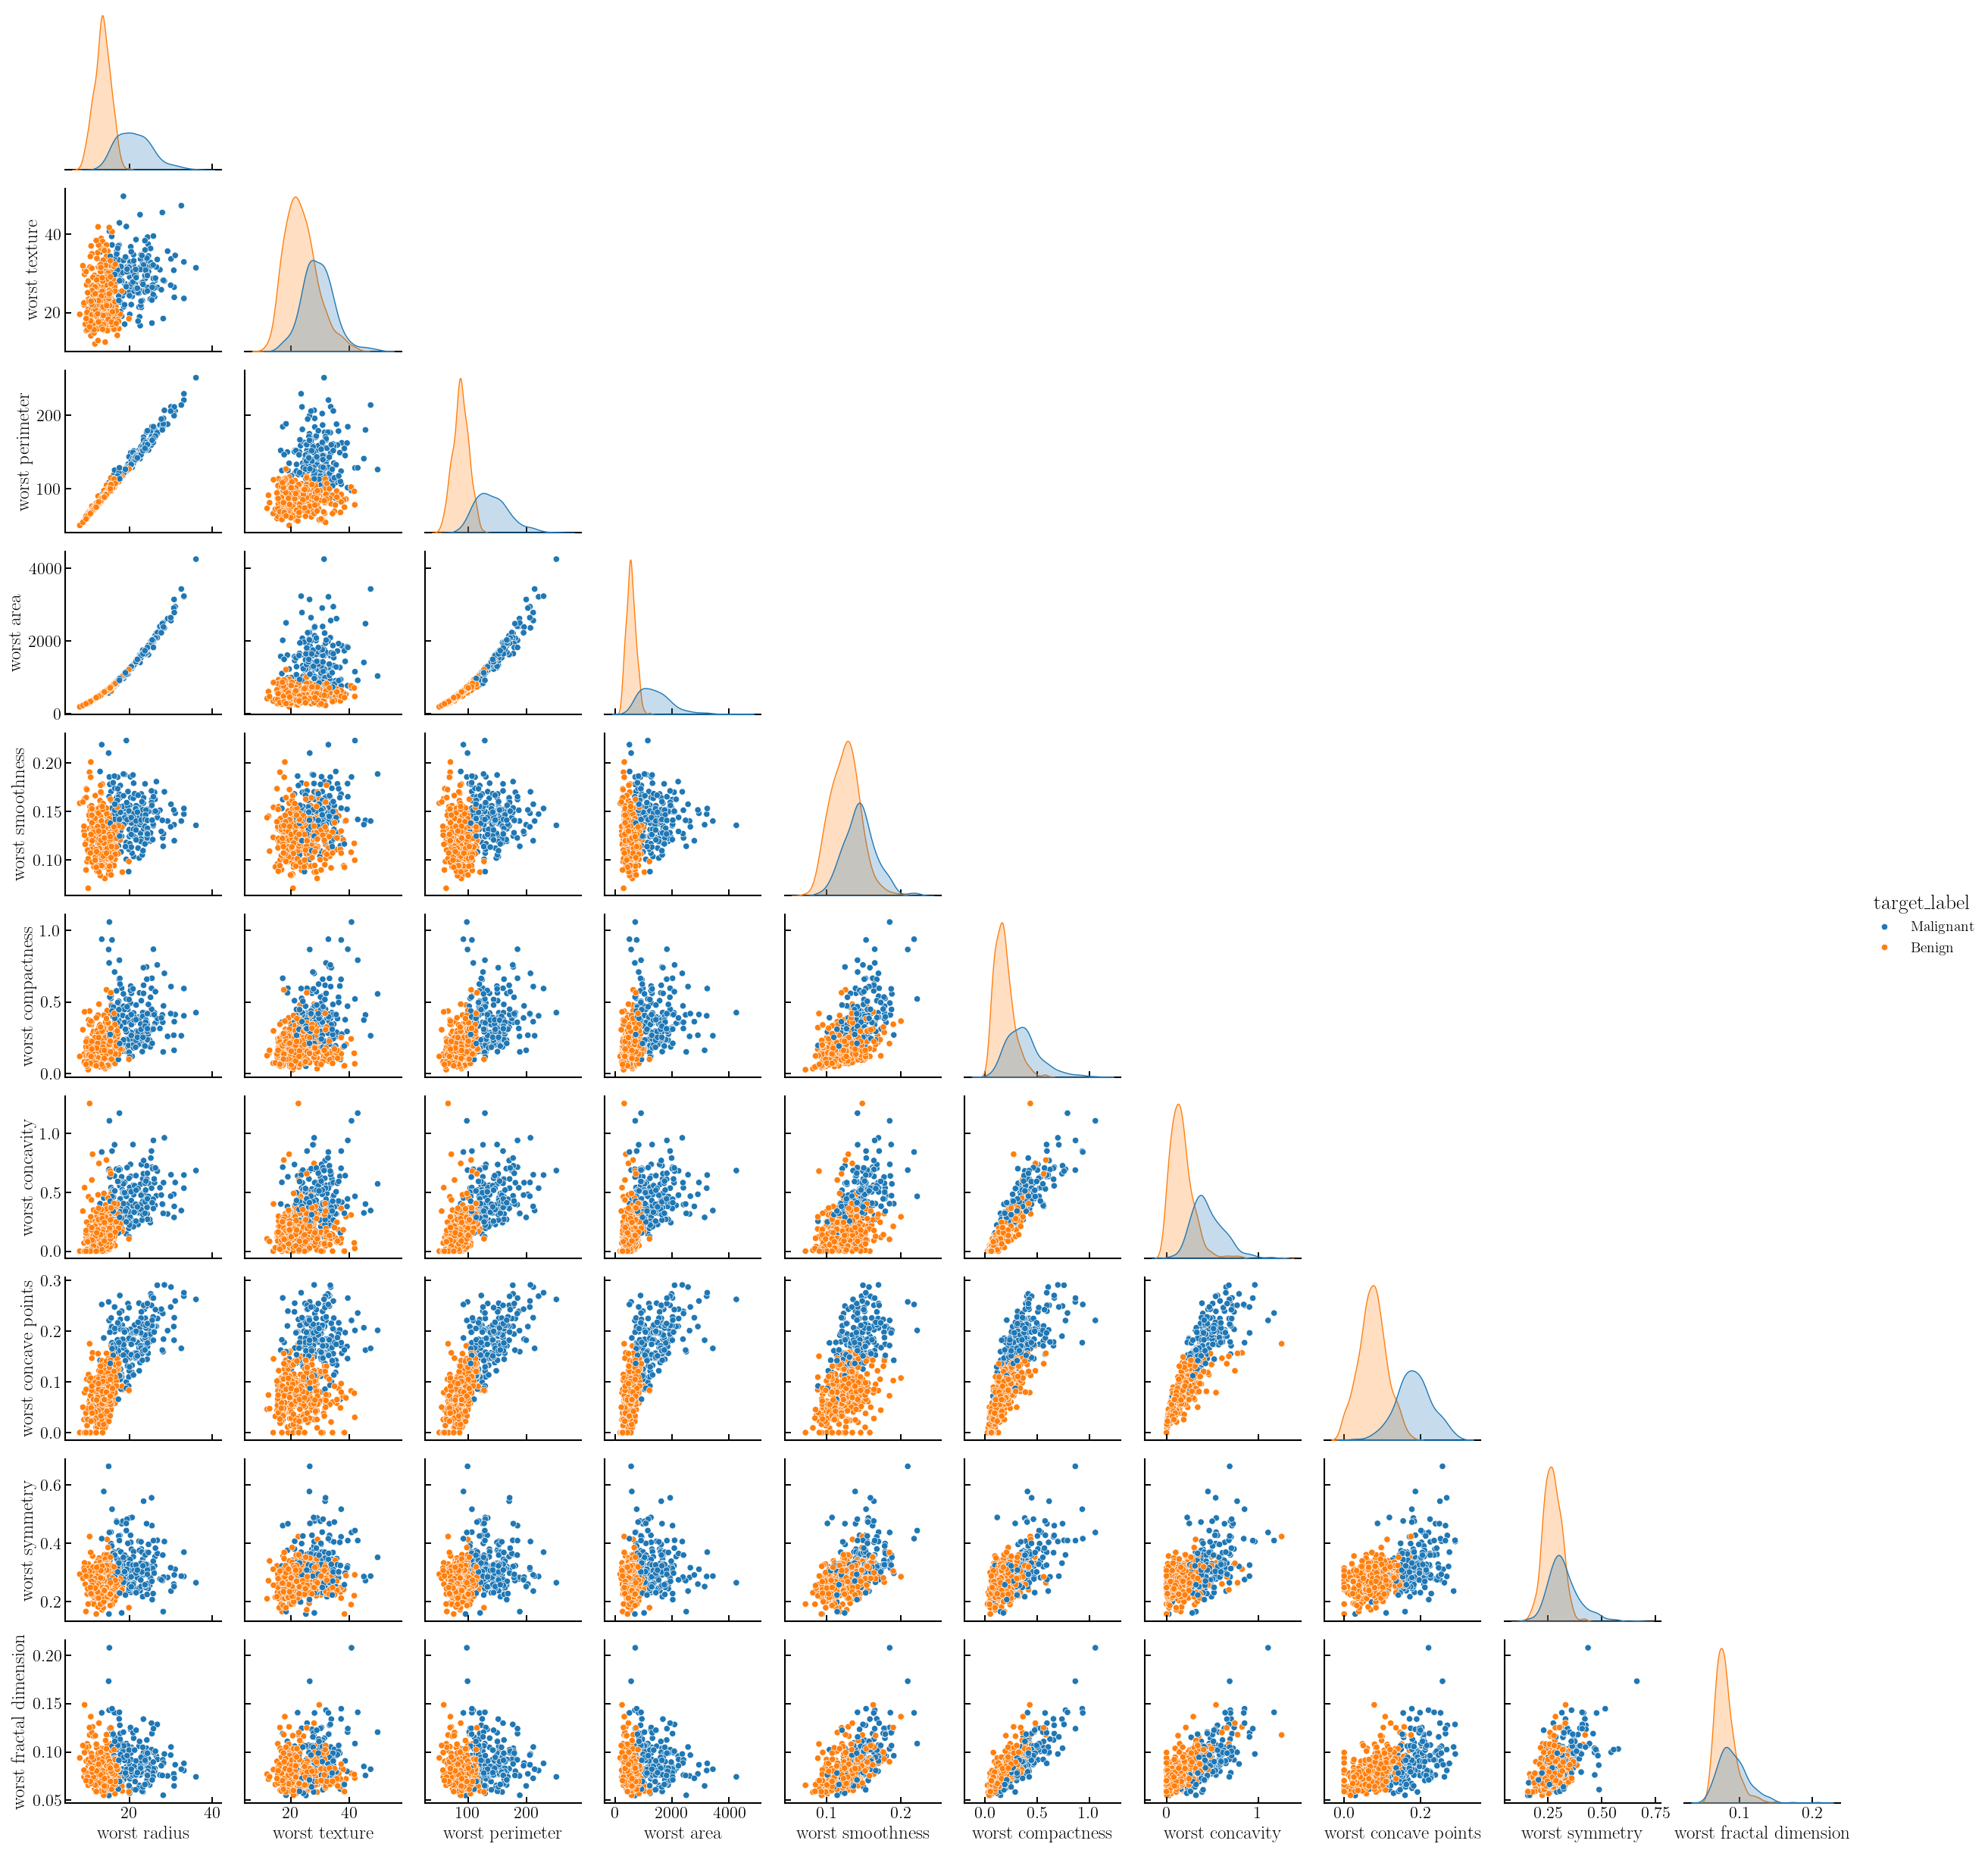

In [4]:
# The dataset has 30 features, so we split them in 3 groups for plotting
features = df.drop(columns="target").columns

# Make an auxiliary column to have more informative legends
df['target_label'] = df['target'].map({0: 'Benign', 1: 'Malignant'})

sns.pairplot(
    data=df,
    vars=features[:10],
    corner=True,
    hue="target_label"
)

sns.pairplot(
    data=df,
    vars=features[10:20],
    corner=True,
    hue="target_label"
)

sns.pairplot(
    data=df,
    vars=features[20:30],
    corner=True,
    hue="target_label"
)

# Drop the auxiliary column
df.drop('target_label', axis=1, inplace=True)

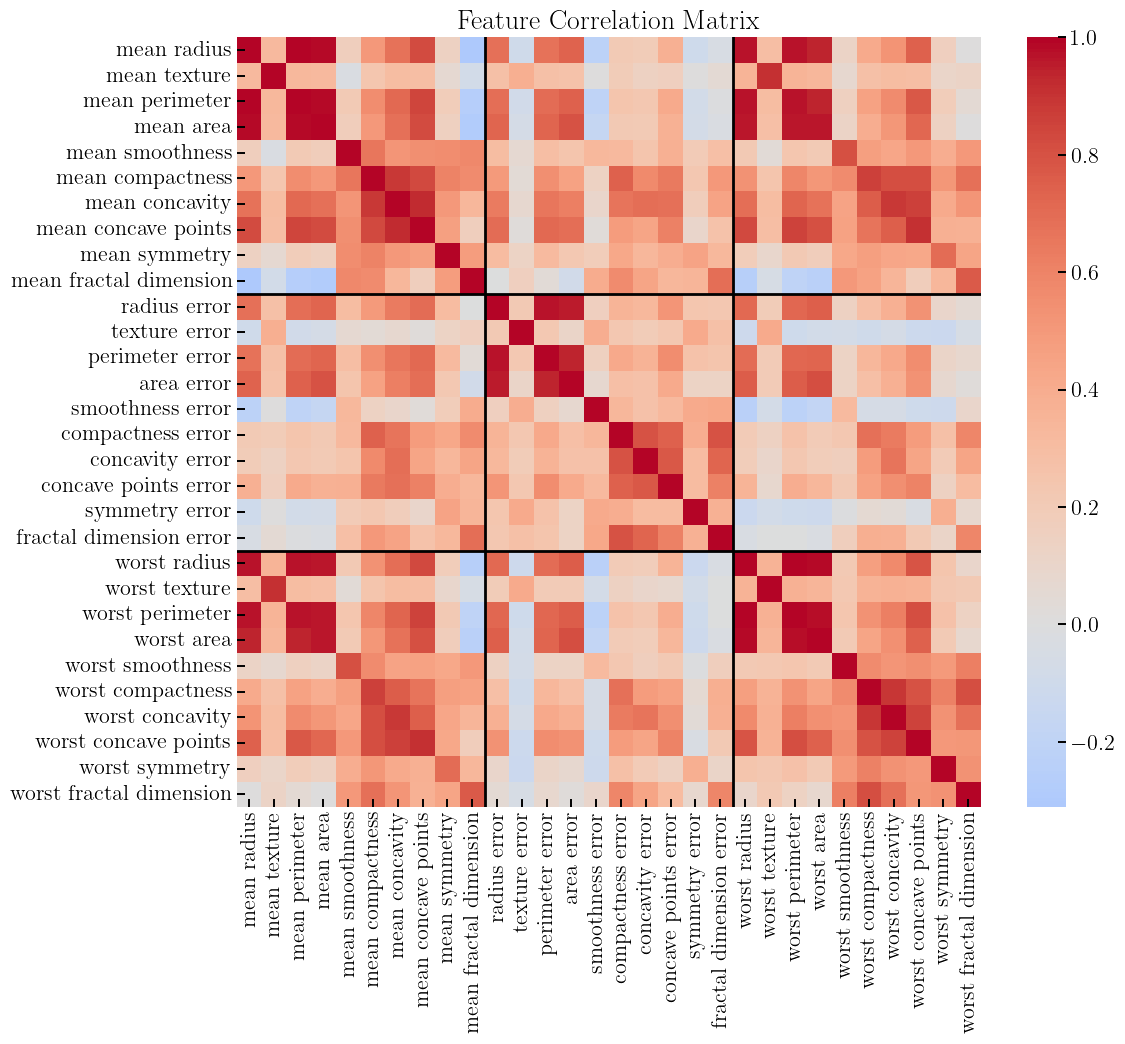

In [5]:
corr = df.drop(columns="target").corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)

# Add black lines at positions 10 and 20
for pos in [10, 20]:
    ax.axvline(x=pos, color='black', linewidth=2)
    ax.axhline(y=pos, color='black', linewidth=2)

plt.title("Feature Correlation Matrix")
plt.show()

### Control: concativity can have mean values of zero, but the other measurements are also zero

In [6]:
df.loc[
    df["mean concavity"] == 0,
    ["mean concavity", "concavity error", "worst concavity"]
]

,mean concavity,concavity error,worst concavity
101,0.0,0.0,0.0
140,0.0,0.0,0.0
174,0.0,0.0,0.0
175,0.0,0.0,0.0
192,0.0,0.0,0.0
314,0.0,0.0,0.0
391,0.0,0.0,0.0
473,0.0,0.0,0.0
538,0.0,0.0,0.0
550,0.0,0.0,0.0


## Explore which features are most informative for the classification models

We build different combinations of features (mean, erros, worst).
For the engineered ratios, when mean=0, the ratio is also set to zero

In [7]:
quantities = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave points",
    "symmetry",
    "fractal dimension",
]

mean_features = [f"mean {q}" for q in quantities]
error_features = [f"{q} error" for q in quantities]
worst_features = [f"worst {q}" for q in quantities]
ratio_features = [f"{q} worst/mean" for q in quantities]

# 1. Mean
X1 = df[mean_features].copy()
y1 = df["target"].copy()

# 2. Mean + errors
X2 = df[mean_features + error_features].copy()
y2 = df["target"].copy()

# 6. Mean + worst
X6 = df[mean_features + worst_features].copy()
y6 = df["target"].copy()

# 3. Mean + errors + worst
X3 = df[mean_features + error_features + worst_features].copy()
y3 = df["target"].copy()

# 4. Mean relative worst
X4 = df[mean_features].copy()
for q in quantities:
    X4[f"{q} worst/mean"] = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"worst {q}"] / df[f"mean {q}"])
y4 = df["target"].copy()

# 5. Mean + relative errors + relative worst
X5 = df[mean_features].copy()
for q in quantities:
    X5[f"{q} error/mean"] = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"{q} error"] / df[f"mean {q}"])
    X5[f"{q} worst/mean"] = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"worst {q}"] / df[f"mean {q}"])
y4 = df["target"].copy()
y5 = df["target"].copy()

In [8]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=42)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, stratify=y3, random_state=42)

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X4, y4, test_size=0.2, stratify=y4, random_state=42)

X_train5, X_test5, y_train5, y_test5 = train_test_split(
    X5, y5, test_size=0.2, stratify=y5, random_state=42)

X_train6, X_test6, y_train6, y_test6 = train_test_split(
    X6, y6, test_size=0.2, stratify=y6, random_state=42)

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_rf(X, y):
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "recall": "recall",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    return {
        metric: (
            scores[f"test_{metric}"].mean(),
            scores[f"test_{metric}"].std()
        )
        for metric in ["accuracy", "recall", "roc_auc"]
    }

results = {
    "Mean": evaluate_rf(X1, y1),
    "Mean + error": evaluate_rf(X2, y2),
    "Mean + worst": evaluate_rf(X6, y6),
    "Mean + error + worst": evaluate_rf(X3, y3),
    "Mean + relative worst": evaluate_rf(X4, y4),
    "Mean + relative error + relative worst": evaluate_rf(X4, y4),
}

for dataset, metrics in results.items():
    print(f"\n{dataset}")
    
    for metric, (mean, std) in metrics.items():
        print(f"  {metric:8s}: {mean:.3f} ± {std:.3f}")


Mean
  accuracy: 0.942 ± 0.014
  recall  : 0.915 ± 0.048
  roc_auc : 0.986 ± 0.005

Mean + error
  accuracy: 0.940 ± 0.014
  recall  : 0.906 ± 0.042
  roc_auc : 0.986 ± 0.007

Mean + worst
  accuracy: 0.961 ± 0.017
  recall  : 0.929 ± 0.057
  roc_auc : 0.990 ± 0.008

Mean + error + worst
  accuracy: 0.953 ± 0.013
  recall  : 0.929 ± 0.057
  roc_auc : 0.989 ± 0.008

Mean + relative worst
  accuracy: 0.963 ± 0.014
  recall  : 0.948 ± 0.035
  roc_auc : 0.992 ± 0.007

Mean + relative error + relative worst
  accuracy: 0.963 ± 0.014
  recall  : 0.948 ± 0.035
  roc_auc : 0.992 ± 0.007


# Explore different ML models for the best feature combination
The exploratory analysis revealed that combining mean with relative worst gives the best results.
When mean and worst = 0, we set the ratio worst/mean to zero. 

In [10]:
X = df[mean_features].copy()

for q in quantities:
    ratio = np.where(
        df[f"mean {q}"] == 0,
        0,
        df[f"worst {q}"] / df[f"mean {q}"]
    )

    X[f"{q} worst/mean"] = ratio

y = df["target"].copy()

## Baseline model

In [11]:
logistic_pipeline = Pipeline([
    ("preprocessor", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])


svm_pipeline = Pipeline([
    ("preprocessor", StandardScaler()),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])


rf_pipeline = Pipeline([
    ("preprocessor", "passthrough"),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])


gb_pipeline = Pipeline([
    ("preprocessor", "passthrough"),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])


knn_pipeline = Pipeline([
    ("preprocessor", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "specificity": specificity_scorer,
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "K-Nearest Neighbors": knn_pipeline
}

results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        metric: (
            scores[f"test_{metric}"].mean(),
            scores[f"test_{metric}"].std()
        )
        for metric in scoring
    }

In [13]:
results_df = pd.DataFrame(
    {
        model: {
            metric: f"{mean * 100:.1f} ± {std * 100:.1f}%"
            for metric, (mean, std) in metrics.items()
        }
        for model, metrics in results.items()
    }
).T

results_df.index.name = "Model"

results_df

,accuracy,recall,specificity,roc_auc
Model,,,,
Logistic Regression,97.4 ± 1.8%,94.3 ± 3.2%,99.2 ± 1.1%,99.1 ± 1.3%
SVM,97.4 ± 1.7%,93.9 ± 4.1%,99.4 ± 0.7%,99.4 ± 0.7%
Random Forest,97.5 ± 1.7%,96.2 ± 2.8%,98.3 ± 2.0%,99.1 ± 0.8%
Gradient Boosting,97.5 ± 1.4%,95.3 ± 3.3%,98.9 ± 0.6%,99.4 ± 0.7%
K-Nearest Neighbors,95.6 ± 1.7%,88.7 ± 4.6%,99.7 ± 0.6%,98.3 ± 0.8%


## Hyperparameter tuning

In [14]:
# I made a denser grid after some broad sampling
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 0.3, 1, 1.5, 2, 3]
    },

    "SVM": {
        "classifier__C": [0.1, 1, 2, 4, 8, 10, 20],
        "classifier__gamma": ["scale", 0.03, 0.1, 0.3, 1]
    },

    "Random Forest": {
        "classifier__n_estimators": [150, 180, 200],
        "classifier__max_depth": [None, 5, 8, 10, 12],
        "classifier__min_samples_leaf": [1, 2, 5]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [100, 130, 200],
        "classifier__learning_rate": [0.05, 0.1, 0.15, 0.2],
        "classifier__max_depth": [1, 2, 3]
    },

    "K-Nearest Neighbors": {    
        "classifier__n_neighbors": [2, 3, 4, 5, 7, 9],
        "classifier__weights": ['uniform', 'distance'],
        "classifier__metric": ['euclidean', 'manhattan']
    }
}

In [15]:
models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "K-Nearest Neighbors": knn_pipeline
}

In [16]:
tuned_models = {}
tuning_results = {}

# F1-score balances precision and recall
f1_scorer = make_scorer(f1_score)

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        #scoring="roc_auc",
        scoring=f1_scorer,
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X, y)

    tuned_models[name] = grid.best_estimator_

    tuning_results[name] = {
        "best_params": grid.best_params_,
        #"best_roc_auc": grid.best_score_
        "best_f1_score": grid.best_score_
    }

    print(f"\n{name}")
    print(f"  Best parameters: {grid.best_params_}")
    #print(f"  Best ROC-AUC:    {grid.best_score_:.3f}")
    print(f"  Best F1-score:    {grid.best_score_:.3f}")


Logistic Regression
  Best parameters: {'classifier__C': 1.5}
  Best F1-score:    0.966

SVM
  Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale'}
  Best F1-score:    0.969

Random Forest
  Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 180}
  Best F1-score:    0.967

Gradient Boosting
  Best parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
  Best F1-score:    0.983

K-Nearest Neighbors
  Best parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 2, 'classifier__weights': 'distance'}
  Best F1-score:    0.943


In [17]:
results_tuned = {}

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results_tuned[name] = {
        metric: (
            scores[f"test_{metric}"].mean(),
            scores[f"test_{metric}"].std()
        )
        for metric in scoring
    }

In [18]:
results_tuned_df = pd.DataFrame(
    {
        model: {
            metric: f"{mean * 100:.1f} ± {std * 100:.1f}%"
            for metric, (mean, std) in metrics.items()
        }
        for model, metrics in results_tuned.items()
    }
).T

results_tuned_df.index.name = "Model"

results_tuned_df

,accuracy,recall,specificity,roc_auc
Model,,,,
Logistic Regression,97.5 ± 1.8%,94.8 ± 3.1%,99.2 ± 1.1%,99.2 ± 1.2%
SVM,97.7 ± 1.8%,95.7 ± 3.8%,98.9 ± 1.1%,99.5 ± 0.6%
Random Forest,97.5 ± 1.4%,96.2 ± 1.9%,98.3 ± 2.0%,99.2 ± 0.7%
Gradient Boosting,98.8 ± 0.9%,96.7 ± 2.4%,100.0 ± 0.0%,99.4 ± 0.9%
K-Nearest Neighbors,96.0 ± 0.7%,90.6 ± 3.0%,99.2 ± 1.1%,96.6 ± 1.8%


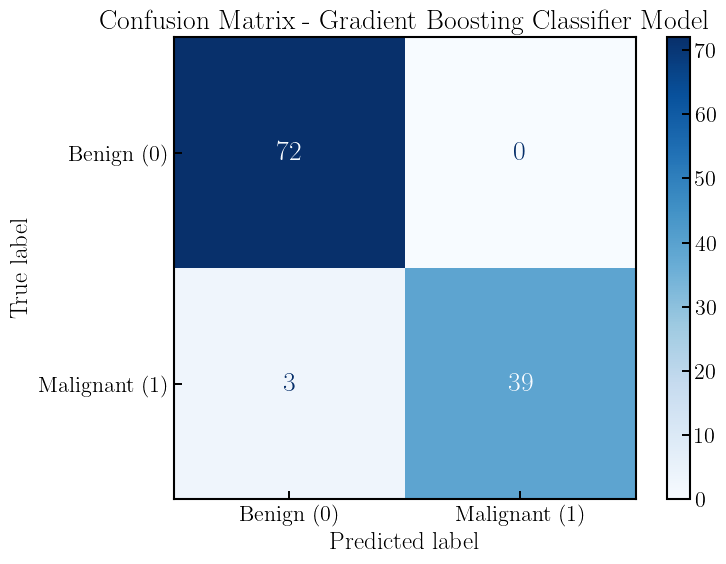

In [36]:
# We calculate and plot the confusion matrix for the best model (Gradient Boosting)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

for model in tuned_models.values():
    model.fit(X_train, y_train)
    
gb_model = tuned_models["Gradient Boosting"] 

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    gb_model, 
    X_test, 
    y_test,
    display_labels=['Benign (0)', 'Malignant (1)'],
    cmap='Blues',
    ax=ax
)
plt.title('Confusion Matrix - Gradient Boosting Classifier Model')
plt.savefig("figs/confusion_matrix.png", dpi=200)
plt.show()

## Feature importance analysis

In [19]:
# We do a final fit of all tuned models
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

for model in tuned_models.values():
    model.fit(X_train, y_train)

In [20]:
importances = {}

for name, model in tuned_models.items():

    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    importances[name] = {
        "mean": result.importances_mean,
        "std": result.importances_std
    }

importance_df = pd.DataFrame(
    {
        model: values["mean"]
        for model, values in importances.items()
    },
    index=X.columns
)

importance_std_df = pd.DataFrame(
    {
        model: values["std"]
        for model, values in importances.items()
    },
    index=X.columns
)


# Filter out KNN from importance_df (very large errorbars)
importance_df = importance_df.drop(columns=["K-Nearest Neighbors"])
importance_std_df = importance_std_df.drop(columns=["K-Nearest Neighbors"])

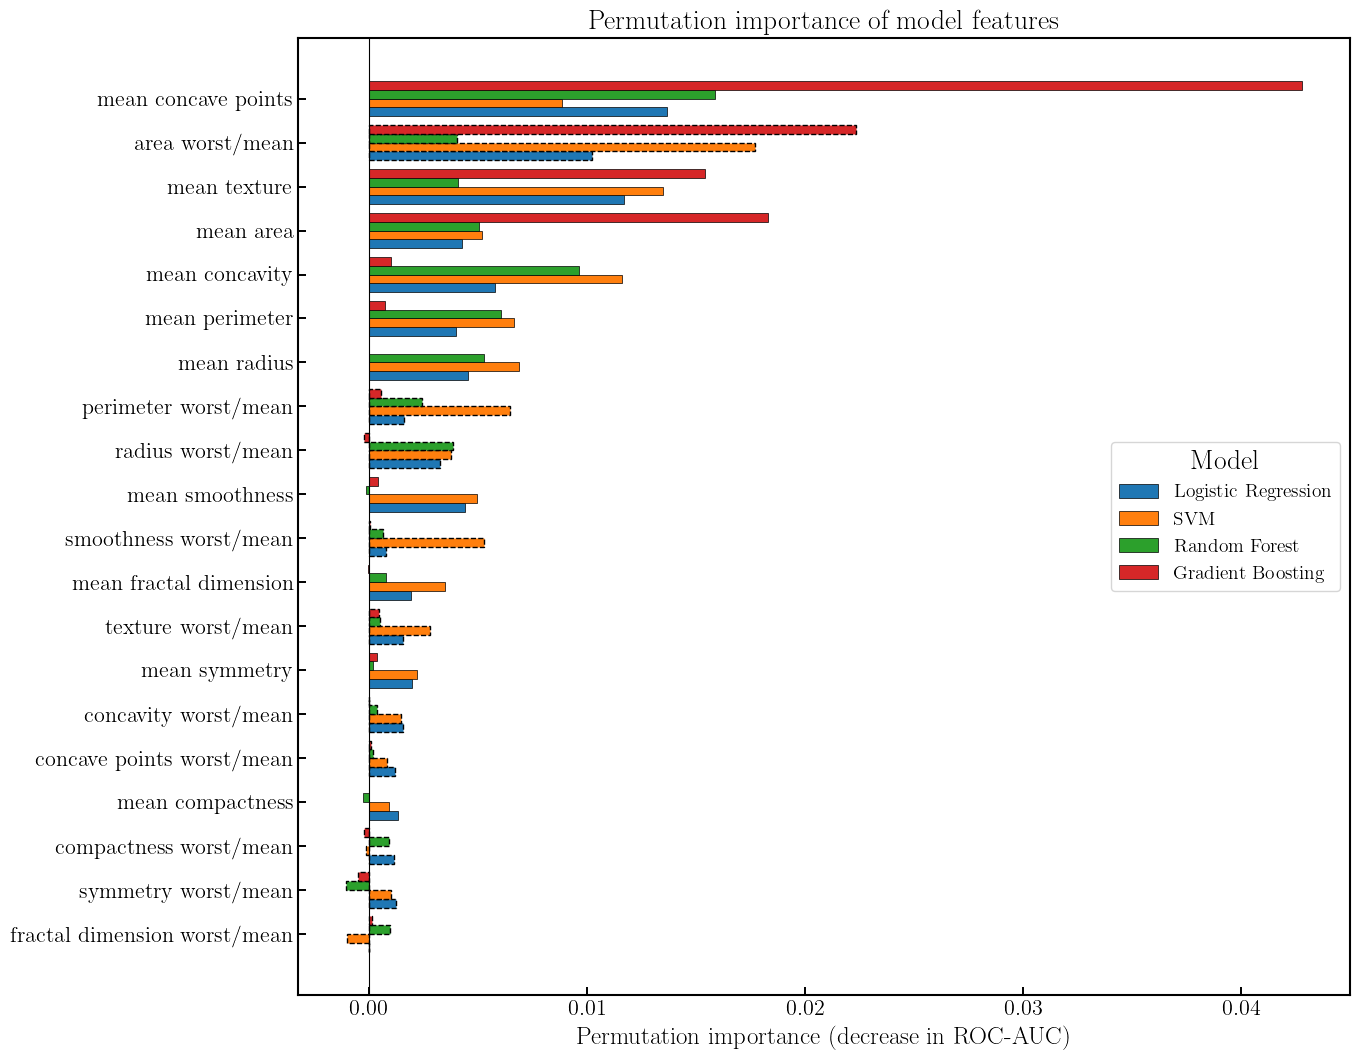

In [31]:
features = mean_features + ratio_features

# Sort features by the average importance across all models
mean_importance = importance_df.mean(axis=1).sort_values()
features = mean_importance.index

fig, ax = plt.subplots(figsize=(14, 11))

n_models = len(importance_df.columns)
n_features = len(features)

bar_height = 0.2
offsets = np.linspace(
    -(n_models - 1) * bar_height / 2,
    (n_models - 1) * bar_height / 2,
    n_models
)

# I removed the errorbars in the plot because it gets too crowded
for i, model in enumerate(importance_df.columns):

    values = importance_df.loc[features, model]
    errors = importance_std_df.loc[features, model]

    is_ratio = np.array(["worst/mean" in feature for feature in features])

    # Means: solid edge
    ax.barh(
        np.arange(n_features)[~is_ratio] + offsets[i],
        values[~is_ratio],
        height=bar_height,
        #xerr=errors[~is_ratio],
        label=model,
        color=f"C{i}",
        capsize=2,
        edgecolor="black",
        linewidth=0.5
    )

    # Ratios: dashed edge
    ax.barh(
        np.arange(n_features)[is_ratio] + offsets[i],
        values[is_ratio],
        height=bar_height,
        #xerr=errors[is_ratio],
        color=f"C{i}",
        capsize=2,
        edgecolor="black",
        linewidth=1.0,
        linestyle="--"
    )

ax.set_yticks(np.arange(n_features))
ax.set_yticklabels(features)

ax.set_xlabel("Permutation importance (decrease in ROC-AUC)")
ax.set_title("Permutation importance of model features")

ax.legend(title="Model", loc="center right")

ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("figs/feature_importance.png", dpi=200)
plt.show()

# Final test: using an ensemble

In [24]:
from sklearn.ensemble import StackingClassifier, VotingClassifier

# 1. Use weighted voting
cv_scores = [tuning_results[name]['best_f1_score'] for name in models.keys()]

# Normalize weights
weights = np.array(cv_scores) / np.sum(cv_scores)

voting_clf = VotingClassifier(
    estimators=list(models.items()),
    voting='soft',
    weights=weights
)

# 2. Cross-validate the ensemble
cv_scores_ensemble = cross_val_score(
    voting_clf, X, y, 
    scoring='f1', 
    cv=5
)
print(f"Ensemble F1: {cv_scores_ensemble.mean()*100:.1f} ± {cv_scores_ensemble.std()*100:.1f}%")

Ensemble F1: 97.8 ± 1.4%


In [25]:
# Evaluate ensemble with cross-validation
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "specificity": specificity_scorer,
    "roc_auc": "roc_auc"
}

cv_scores = cross_validate(
    voting_clf, X, y,
    scoring=scoring,
    cv=5
)

# Add to results_tuned in one line
results_tuned["Ensemble"] = {
    "accuracy": (cv_scores['test_accuracy'].mean(), cv_scores['test_accuracy'].std()),
    "recall": (cv_scores['test_recall'].mean(), cv_scores['test_recall'].std()),
    "specificity": (cv_scores['test_specificity'].mean(), cv_scores['test_specificity'].std()),
    "roc_auc": (cv_scores['test_roc_auc'].mean(), cv_scores['test_roc_auc'].std())
}

# Create the formatted DataFrame
results_tuned_df = pd.DataFrame(
    {
        model: {
            metric: f"{mean * 100:.1f} ± {std * 100:.1f}%"
            for metric, (mean, std) in metrics.items()
        }
        for model, metrics in results_tuned.items()
    }
).T

results_tuned_df.index.name = "Model"
results_tuned_df

,accuracy,recall,specificity,roc_auc
Model,,,,
Logistic Regression,97.5 ± 1.8%,94.8 ± 3.1%,99.2 ± 1.1%,99.2 ± 1.2%
SVM,97.7 ± 1.8%,95.7 ± 3.8%,98.9 ± 1.1%,99.5 ± 0.6%
Random Forest,97.5 ± 1.4%,96.2 ± 1.9%,98.3 ± 2.0%,99.2 ± 0.7%
Gradient Boosting,98.8 ± 0.9%,96.7 ± 2.4%,100.0 ± 0.0%,99.4 ± 0.9%
K-Nearest Neighbors,96.0 ± 0.7%,90.6 ± 3.0%,99.2 ± 1.1%,96.6 ± 1.8%
Ensemble,98.4 ± 1.0%,95.8 ± 2.7%,100.0 ± 0.0%,99.5 ± 0.6%
